# Data description
| Variable Name | Description | Type |
|----------|----------|----------|
| SeriousDlqin2yrs | Person experienced 90 days past due delinquency or worse   | Y/N |
| RevolvingUtilizationOfUnsecuredLines | Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits | percentage |
| age | Age of borrower in years |	integer |
| NumberOfTime30-59DaysPastDueNotWorse	| Number of times borrower has been 30-59 days past due but no worse in the last 2 years	| integer |
| DebtRatio	| Monthly debt payments, alimony, living costs divided by monthy gross income |	percentage |
| MonthlyIncome	| Monthly income	| real |
|NumberOfOpenCreditLinesAndLoans	| Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)	| integer |
|NumberOfTimes90DaysLate	| Number of times borrower has been 90 days or more past due	| integer |
|NumberRealEstateLoansOrLines	| Number of mortgage and real estate loans including home equity lines of credit	| integer |
|NumberOfTime60-89DaysPastDueNotWorse	| Number of times borrower has been 60-89 days past due but no worse in the last 2 years	| integer |
|NumberOfDependents	| Number of dependents in family excluding themselves (spouse, children etc.)	| integer |


**Target: SeriousDlqin2yrs**

# Анализ данных

In [3]:
import pandas as pd
import numpy as np

DATA = pd.read_csv('data_server/cs-training.csv')

RANDOM_STATE = 42
MLFLOW_URL = 'http://localhost:5050'

In [4]:
DATA.head(3)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [5]:
DATA.drop(columns='Unnamed: 0', inplace=True)

In [6]:
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

В признаках **MonthlyIncome** и **NumberOfDependents** есть много пропущенных значений. Заполним их дальше по ноутбуку.

In [7]:
DATA.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


В данных также присутствуют признаки, которые могут давать схожую информацию: **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse** или **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**. Посмотрим на их корреляцию по ходу анализа данных.

Также, если мы выделим возраст, который выходит за пределы 18-100 лет, то сможем заметить, что в данных есть явный выброс с возрастом 0 лет, исправим его в зависимости от распределения значений этого признака. Возраст больше 100 лет возможен, так что не будем засчитывать такие значения за выбросы.

In [8]:
DATA.loc[DATA['age'] < 18]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [9]:
DATA.loc[DATA['age'] > 100]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
7763,0,0.069167,101,0,50.000000,NaN,2,0,0,0,0.0
19884,0,1.000000,103,0,0.000000,1600.0,3,0,0,0,0.0
25561,0,0.009866,102,0,0.002424,3300.0,3,0,0,0,0.0
40007,0,0.064748,107,0,939.000000,NaN,9,0,1,0,0.0
56761,0,0.003469,105,0,2.000000,NaN,4,0,0,0,NaN
57967,0,0.001397,103,0,1798.500000,1.0,11,0,2,0,0.0
90937,0,0.000000,102,0,0.000000,NaN,12,0,0,0,0.0
93813,0,0.025780,101,0,0.013797,1666.0,5,0,0,0,0.0
96450,0,0.109642,102,0,0.273844,3417.0,7,0,0,0,1.0
105790,0,0.109307,109,0,2141.000000,NaN,17,0,1,0,NaN


# Итог анализа:

1) Заменить выброс с нулевым возрастом

2) Заполнить пропуски в **NumberOfDependents**

3) Заполнить пропущенные значения в **MonthlyIncome**

4) Обработать зависимость признаков **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**

5) Обработать зависимость признаков **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse**

# Обработка данных

## 1) Заменить выброс с нулевым возрастом

Посмотрим на распределение возраста клиентов

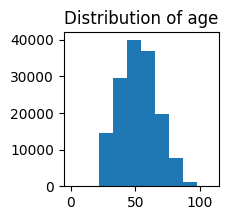

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.hist(DATA['age'])
plt.title('Distribution of age')
plt.show()

Распределение схоже с нормальным, вполне четким видом колокола. Исходя из распределения заполним пропуски средним возрастом:

In [11]:
mean_age = int(DATA['age'].mean())

DATA['age'] = DATA['age'].replace(0, mean_age)

## 2) Заполнить пропуски в **NumberOfDependents**

In [12]:
DATA['NumberOfDependents'].value_counts(dropna=False)

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
NaN      3924
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

Пропуски заполним модой:

In [13]:
mode_dependents = DATA['NumberOfDependents'].mode()[0]

DATA['NumberOfDependents'] = DATA['NumberOfDependents'].fillna(mode_dependents).astype(int)

## 3) Заполнить пропущенные значения в **MonthlyIncome**

In [14]:
DATA['MonthlyIncome'].value_counts(dropna=False)

MonthlyIncome
NaN        29731
5000.0      2757
4000.0      2106
6000.0      1934
3000.0      1758
           ...  
16084.0        1
10523.0        1
55250.0        1
9242.0         1
7647.0         1
Name: count, Length: 13595, dtype: int64

Пропусков много, но признак может быть очень полезен для предсказаний. Заполнять пропуским одним значением будет неправильным решением, поскольку ежемесячный доход имеет более сложную зависимость. 

Заполним пропуски предсказаниями другой модели:

In [15]:
X_instance = DATA.loc[DATA['MonthlyIncome'].notna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])
X_empty = DATA.loc[DATA['MonthlyIncome'].isna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])

y_instance = DATA.loc[DATA['MonthlyIncome'].notna(), 'MonthlyIncome']

Выберем модель для предсказания ежемесячного дохода. Основной метрикой для сравнения будет MSE, так как нам важно штрафовать модель за большие ошибки, поскольку мы добиваемся максимально возможной точности. Для сравнения моделей между собой воспользуемся R2, чтобы оценить их относительно объясненной дисперсией.

In [16]:
import mlflow
import os

os.environ['USER'] = 'Maxim Balabanov'

mlflow.set_tracking_uri(MLFLOW_URL)
mlflow.set_experiment('Regressor for MonthlyIncome')

/Users/bloededhoine/Lands/territory/.venv/lib/python3.12/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
2025/10/23 15:00:28 INFO mlflow.tracking.fluent: Experiment with name 'Regressor for MonthlyIncome' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket/artifacts--serve-artifacts/445384568052987376', creation_time=1761220828407, experiment_id='445384568052987376', last_update_time=1761220828407, lifecycle_stage='active', name='Regressor for MonthlyIncome', tags={}>

### Линейные модели

In [31]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
def linear_objective(trial):
    with mlflow.start_run(run_name=f'Linear_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'degree': degree
        })

        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', LinearRegression())
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Lasso
def lasso_objective(trial):
    with mlflow.start_run(run_name=f'Lasso_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Lasso(alpha=alpha, random_state=RANDOM_STATE))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Ridge
def ridge_objective(trial):
    with mlflow.start_run(run_name=f'Ridge_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Ridge(alpha=alpha))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

In [32]:
#Linear Regression
with mlflow.start_run(run_name='Linear Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(linear_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Lasso
with mlflow.start_run(run_name='Lasso Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(lasso_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Ridge
with mlflow.start_run(run_name='Ridge Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(ridge_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)

    mlflow.set_tag('Optimizer', 'Optuna')

[I 2025-10-19 13:13:23,335] A new study created in memory with name: no-name-aa4868b2-3621-4f63-a89f-562f1d6f2730
2025/10/19 13:13:25 INFO mlflow.tracking._tracking_service.client: 🏃 View run Linear_trial_0 at: http://89.169.181.151:5050/#/experiments/864426210001782524/runs/d1e38e3a6f2240b0bc8ed1ea8075edec.
2025/10/19 13:13:25 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89.169.181.151:5050/#/experiments/864426210001782524.
[I 2025-10-19 13:13:29,175] Trial 0 finished with value: 21979973632.303722 and parameters: {'with_mean': False, 'with_std': True, 'degree': 3}. Best is trial 0 with value: 21979973632.303722.
2025/10/19 13:13:31 INFO mlflow.tracking._tracking_service.client: 🏃 View run Linear_trial_1 at: http://89.169.181.151:5050/#/experiments/864426210001782524/runs/56febbdb11f148a99940d53cc195f11c.
2025/10/19 13:13:31 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89.169.181.151:5050/#/experiments/864426210001782524.
[

### Модели деревьев

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import optuna

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

# Gradient Boosting Regression
def gradient_objective(trial):
    with mlflow.start_run(run_name=f'GradientBoosting_trial_{trial.number}', nested=True):
        
        loss = trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber', 'quantile'])
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'loss': loss,
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth
        })

        model = GradientBoostingRegressor(
            loss=loss,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse
    
    # LightGBM Regressor
def lightgbm_objective(trial):
    import re
    X_clean = X_instance.rename(columns=lambda c: re.sub(r'[^\w\d_]+', '_', c))
    
    with mlflow.start_run(run_name=f'LightGBM_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0)
        n_estimators = trial.suggest_int('n_estimators', 50, 1000)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        num_leaves = trial.suggest_int('num_leaves', 2, 300)
        min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 10, 100)
        lambda_l1 = trial.suggest_float('lambda_l1', 0.0, 5.0),
        lambda_l2 = trial.suggest_float('lambda_l2', 0.0, 5.0),
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'num_leaves': num_leaves,
            'min_data_in_leaf': min_data_in_leaf,
            'lambda_l1': lambda_l1,
            'lambda_l2': lambda_l2
        })

        model = LGBMRegressor(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            num_leaves=num_leaves,
            lambda_l1=lambda_l1,
            lambda_l2=lambda_l2,
            min_data_in_leaf=min_data_in_leaf,
            random_state=42,
            verbose=-1
        )
        
        preds = cross_val_predict(model, X_clean, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse
    
    # XGBoost Regressor
def xgboost_objective(trial):
    with mlflow.start_run(run_name=f'XGBoost_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0)
        n_estimators = trial.suggest_int('n_estimators', 50, 1000)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        alpha = trial.suggest_float('alpha', 0, 5)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'alpha': alpha
        })

        model = XGBRegressor(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            alpha=alpha
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

OSError: dlopen(/Users/bloededhoine/Lands/territory/.venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/bloededhoine/Lands/territory/.venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

In [47]:
#GradientBoosting
with mlflow.start_run(run_name='GradientBoosting Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(gradient_objective, n_trials=5)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#LightGBM
with mlflow.start_run(run_name='LightGBM Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(lightgbm_objective, n_trials=40)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#XGBoost
with mlflow.start_run(run_name='XGBoost Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(xgboost_objective, n_trials=40)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)

    mlflow.set_tag('Optimizer', 'Optuna')

[I 2025-10-19 13:48:15,829] A new study created in memory with name: no-name-ee327896-b003-4f89-96fd-c543b1cc4fc7
2025/10/19 13:48:16 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_trial_0 at: http://89.169.181.151:5050/#/experiments/864426210001782524/runs/6a2a7d3d0dbb4ab78729f3430e398bb3.
2025/10/19 13:48:16 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89.169.181.151:5050/#/experiments/864426210001782524.
[I 2025-10-19 13:48:16,295] Trial 0 finished with value: 174593667.79873258 and parameters: {'learning_rate': 0.1594379839552926, 'n_estimators': 142, 'max_depth': 4, 'alpha': 2.254870265591991}. Best is trial 0 with value: 174593667.79873258.
2025/10/19 13:48:16 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_trial_1 at: http://89.169.181.151:5050/#/experiments/864426210001782524/runs/258a3c126a4640e4a12e94b43221799f.
2025/10/19 13:48:16 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89

По результатам эксперимента лучшей моделью является XGBoost:

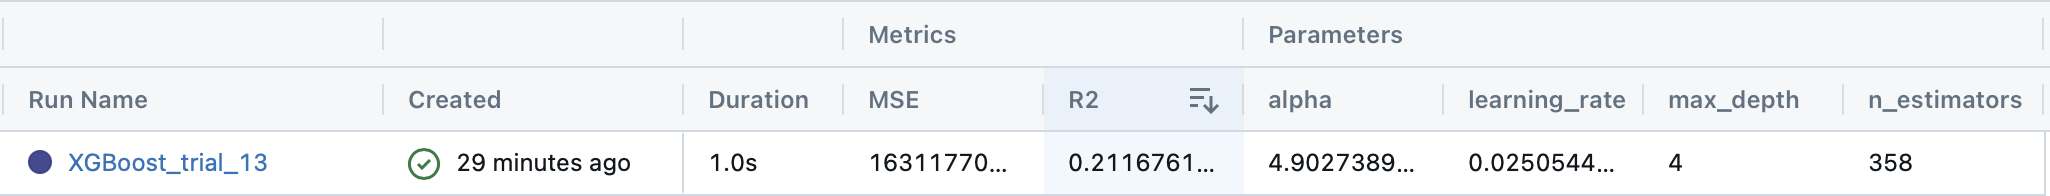

Метрика R² показывает, насколько модель предсказывает лучше, чем если просто подставлять среднее

R² = 0 - модель не лучше среднего.
R² > 0 - модель лучше, чем просто среднее значение.
R² < 0 - модель хуже, чем просто среднее значение.

В нашем случае R² = 0.21, что очень неплохо, учитывая, что мы предсказываем ежемесячный доход по тем немногим данным, которые у нас имеются

In [17]:
from xgboost import XGBRegressor

In [21]:
model = XGBRegressor(
    learning_rate=0.025054449589821393,
    n_estimators=358,
    max_depth=4,
    alpha=4.902738920433285
)

model.fit(X_instance, y_instance)

y_fill = model.predict(X_empty)

y_fill[y_fill < 0] = 0

In [ ]:
import pickle

with open('filler_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [22]:
DATA.loc[DATA['MonthlyIncome'].isna(), 'MonthlyIncome'] = y_fill

## 4 и 5) Обработать зависимость некоторых признаков 

<Axes: >

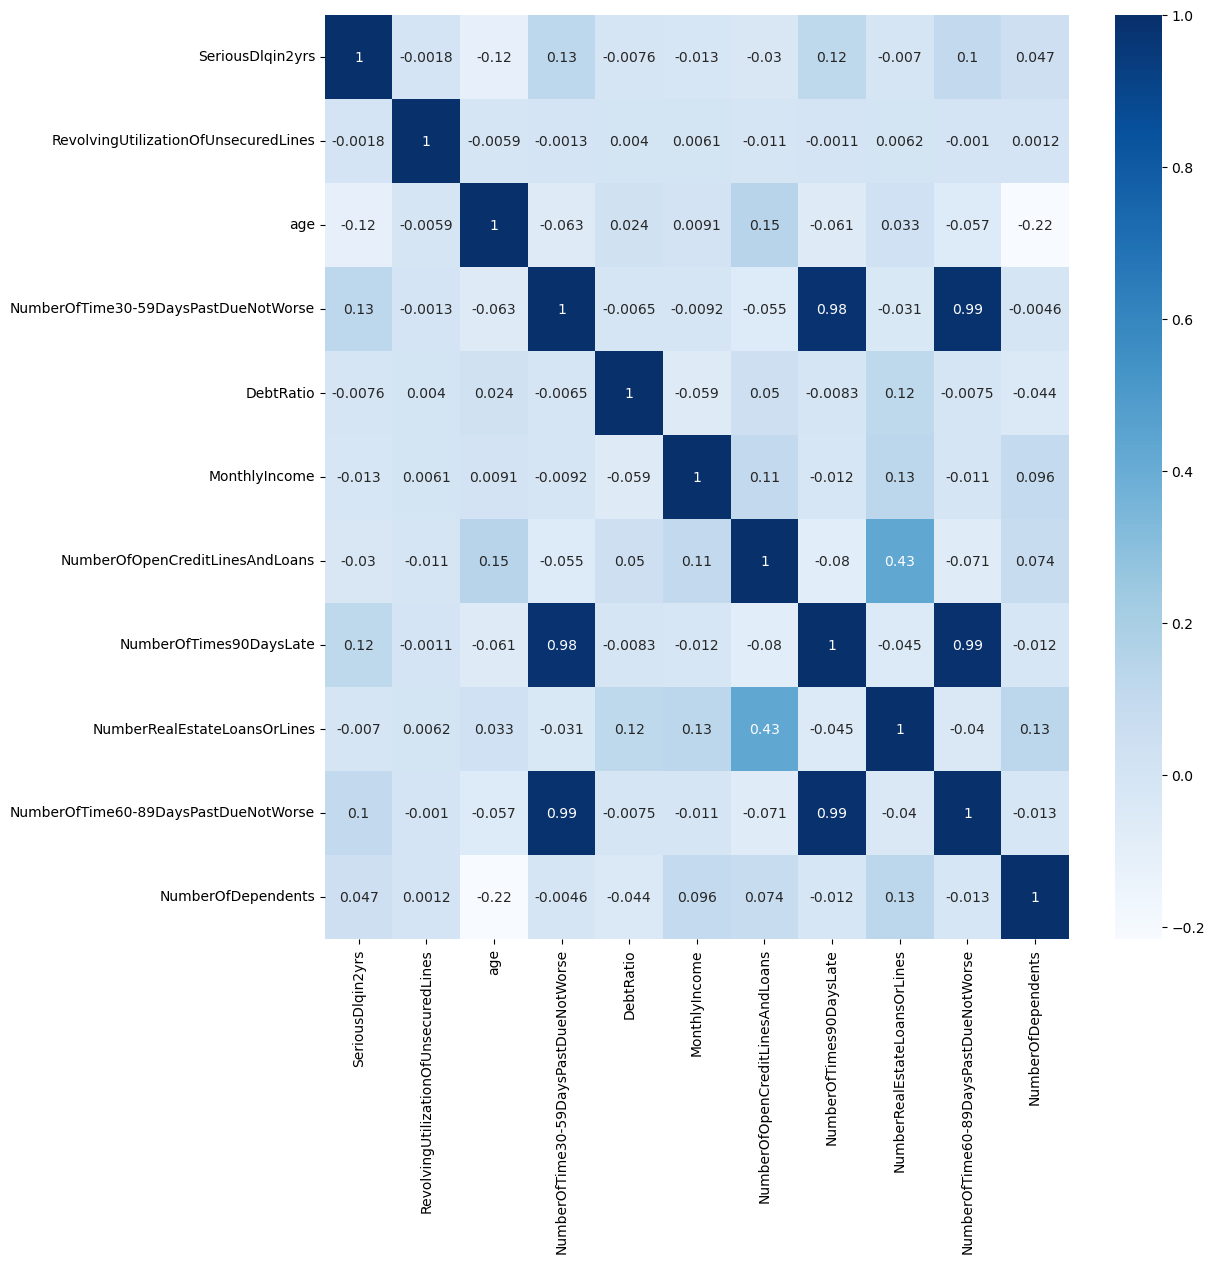

In [ ]:
import seaborn as sb

plt.figure(figsize=(12, 12))
corr = DATA.corr()
sb.heatmap(corr, cmap='Blues', annot=True)

Существует значительная зависимость между **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**, так как они отражают наличие задолженностей. Объединим их в один признак наличия задолженностей **HasLoan**

In [23]:
DATA['HasLoans'] = DATA['NumberOfOpenCreditLinesAndLoans'] + DATA['NumberRealEstateLoansOrLines']

In [24]:
DATA['HasLoans'].describe()

count    150000.000000
mean          9.471000
std           5.727394
min           0.000000
25%           5.000000
50%           9.000000
75%          13.000000
max         112.000000
Name: HasLoans, dtype: float64

In [25]:
DATA['HasAlotLoans'] = DATA['HasLoans'].map(lambda x: 1 if x > 5 else 0)
DATA.drop(columns=['HasLoans', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines'], inplace=True)

**NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse** так же сильно связаны между собой, поскольку обозначают просроченные выплаты. Объединим эти три признака в один - были ли опоздания с выплатами **HasLatePayments**

In [26]:
DATA['NumbersOfLate'] = DATA['NumberOfTime30-59DaysPastDueNotWorse'] + DATA['NumberOfTime60-89DaysPastDueNotWorse'] + DATA['NumberOfTimes90DaysLate']

In [27]:
DATA['HasLatePayments'] = DATA['NumbersOfLate'].map(lambda x: 1 if x > 0 else 0)
DATA.drop(columns=['NumbersOfLate','NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate'], inplace=True)

# Model Training

В данных присутствует дисбаланс классов тагрета:

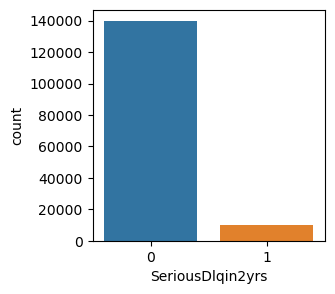

In [24]:
import seaborn as sns

plt.figure(figsize=(3, 3))
sns.countplot(x='SeriousDlqin2yrs', data=DATA)
plt.show()

In [29]:
X = DATA.drop(columns='SeriousDlqin2yrs')
y = DATA['SeriousDlqin2yrs']

Поэтому в моделях, чувствительных в весам классов, будем задавать class_weight сбалансированным:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

In [29]:
mlflow.set_experiment('Classifier for Target')

<Experiment: artifact_location='s3://mlflow-bucket/artifacts--serve-artifacts/932737427523173445', creation_time=1760892348311, experiment_id='932737427523173445', last_update_time=1760892348311, lifecycle_stage='active', name='Classifier for Target', tags={}>

В качестве метрики выберем f1-score, поскольку нам необходимо в равной степени иметь высокие recall и precision. Также, так как в данных присутсвует дисбаланс классов, f1 в отличие от roc-auc будет честнее оценивать предсказательную способность модели.

In [34]:
# Logistic Regression
def logistic_objective(trial):
    with mlflow.start_run(run_name=f'Logistic_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        C = trial.suggest_float('C', 0.001, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'degree': degree,
            'C': C,
        })

        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', LogisticRegression(C=C, class_weight='balanced'))
        ])
        
        preds = cross_val_predict(pipeline, X, y, cv=3)
        preds_proba = cross_val_predict(pipeline, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

# Random Forest
def randomforest_objective(trial):
    with mlflow.start_run(run_name=f'RandomForest_trial_{trial.number}', nested=True):
        
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 8)
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])

        mlflow.log_params({
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'criterion': criterion
        })

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        preds_proba = cross_val_predict(model, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

# Gradient Boosting Classifier
def gradient_objective(trial):
    with mlflow.start_run(run_name=f'GradientBoosting_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 8)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf
        })

        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        preds_proba = cross_val_predict(model, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

# LGBM Classifier
def lgbm_objective(trial):
    with mlflow.start_run(run_name=f'LGBM_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        num_leaves = trial.suggest_int('num_leaves', 10, 150)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'num_leaves': num_leaves
        })

        model = LGBMClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            num_leaves=num_leaves,
            class_weight='balanced'
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        preds_proba = cross_val_predict(model, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

# XGBoost Classifier
def xgboost_objective(trial):
    with mlflow.start_run(run_name=f'XGBoost_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0)
        n_estimators = trial.suggest_int('n_estimators', 50, 1000)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
        })

        model = XGBClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        preds_proba = cross_val_predict(model, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

# KNeighbours
def knn_objective(trial):
    with mlflow.start_run(run_name=f'KNN_trial_{trial.number}', nested=True):
        
        n_neighbors = trial.suggest_int('n_neighbors', 1, 30)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        metric = trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
        
        mlflow.log_params({
            'n_neighbours': n_neighbors,
            'weights': weights,
            'metric': metric
        })

        model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        preds_proba = cross_val_predict(model, X, y, cv=3, method='predict_proba')
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, preds_proba[:, 1])
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'roc_auc': roc_auc,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return f1

In [35]:
# Logistic Regression
with mlflow.start_run(run_name='Logistic Regression'):
    study = optuna.create_study(direction='maximize')
    study.optimize(logistic_objective, n_trials=30)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# Random Forest
with mlflow.start_run(run_name='Random Forest Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(randomforest_objective, n_trials=10)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# Gradient Boosting Classifier
with mlflow.start_run(run_name='Gradient Boosting Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(gradient_objective, n_trials=10)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# LGBM Classifier
with mlflow.start_run(run_name='LGBM Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(lgbm_objective, n_trials=30)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# XGBoost Classifier
with mlflow.start_run(run_name='XGBoost Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(xgboost_objective, n_trials=30)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# KNeighbours
with mlflow.start_run(run_name='KNeighbours Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(knn_objective, n_trials=30)
    mlflow.log_metric('f1', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

[I 2025-10-19 20:36:39,305] A new study created in memory with name: no-name-d3d0f308-0aad-4797-af57-8cb564cdf956
2025/10/19 20:36:47 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN_trial_0 at: http://89.169.181.151:5050/#/experiments/932737427523173445/runs/1f8c24486be54248b3c70833806eae68.
2025/10/19 20:36:47 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89.169.181.151:5050/#/experiments/932737427523173445.
[I 2025-10-19 20:36:47,018] Trial 0 finished with value: 0.01885369532428356 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 0 with value: 0.01885369532428356.
2025/10/19 20:36:56 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN_trial_1 at: http://89.169.181.151:5050/#/experiments/932737427523173445/runs/473bbd454c2b4f94a62c676f13d16253.
2025/10/19 20:36:56 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://89.169.181.151:5050/#/experiments/93273742752

Лучшей моделью оказался LGBM Classifier:

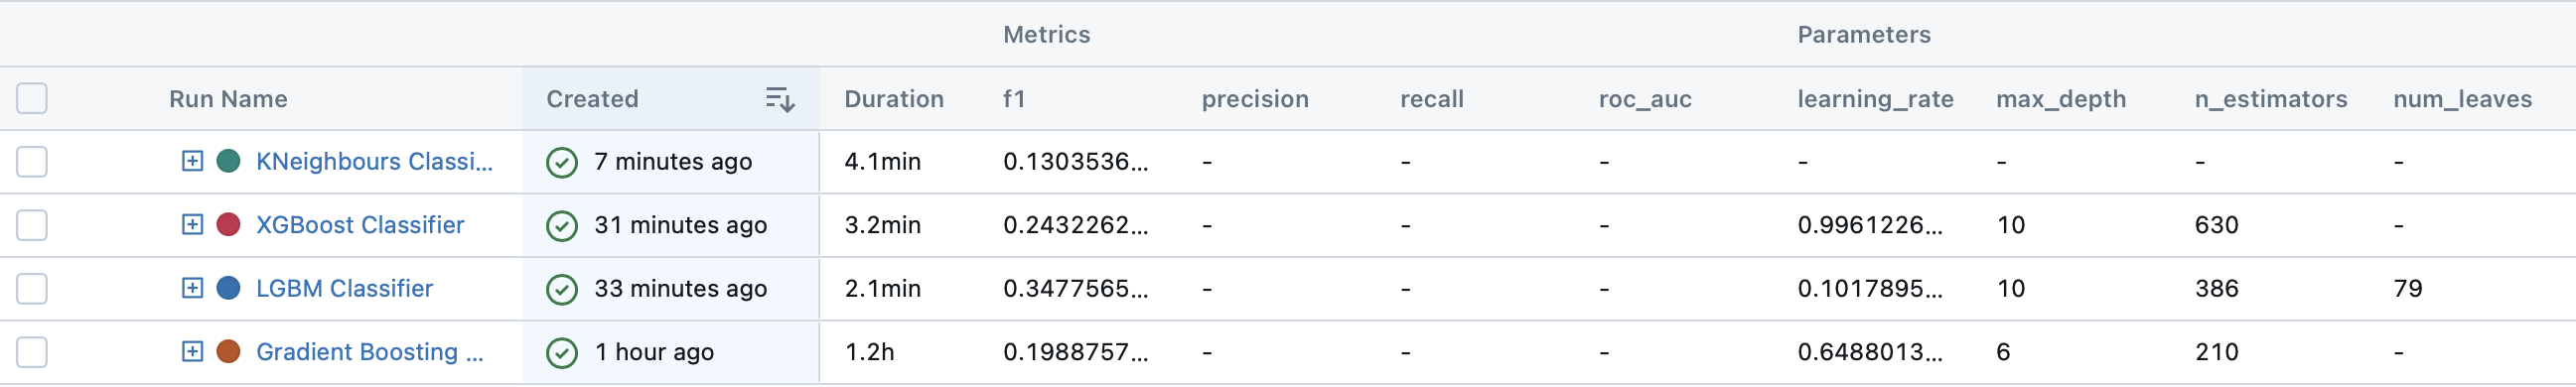

In [33]:
X

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfDependents,HasAlotLoans,HasLatePayments
0,0.766127,45,0.802982,9120.000000,2,1,1
1,0.957151,40,0.121876,2600.000000,1,0,0
2,0.658180,38,0.085113,3042.000000,0,0,1
3,0.233810,30,0.036050,3300.000000,0,0,0
4,0.907239,49,0.024926,63588.000000,0,1,1
...,...,...,...,...,...,...,...
149995,0.040674,74,0.225131,2100.000000,0,0,0
149996,0.299745,44,0.716562,5584.000000,2,0,0
149997,0.246044,58,3870.000000,1015.730164,0,1,0
149998,0.000000,30,0.000000,5716.000000,0,0,0


In [ ]:
from lightgbm import LGBMClassifier


In [32]:
model = LGBMClassifier(
    learning_rate=0.1017895,
    max_depth=10,
    n_estimators=386,
    num_leaves=79
)

model.fit(X, y)

with open('prediction_model.pkl', 'wb') as file:
    pickle.dump(model, file)

[LightGBM] [Info] Number of positive: 10026, number of negative: 139974
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 865
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066840 -> initscore=-2.636275
[LightGBM] [Info] Start training from score -2.636275
